# Assignment 2: Neural Networks

## DTSC-680: Applied Machine Learning

## Name:

### Overview

In this assignment, you will create a neural network to perform a binary classification on a coronavirus dataset.

### Install Tensorflow 2.9.2

In [4]:
# CODE PROVIDED
import subprocess
import sys
from IPython.display import clear_output
def update_libraries():
    tf_desired_version = "2.9.2"

    try:
        import tensorflow as tf
        tf_installed_version = tf.__version__
    except ImportError:
        tf_installed_version = None

    # Update pip to the latest version
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
    print("Pip updated!")
    
    #Check for the right version
    if tf_installed_version != tf_desired_version:
        print(f"Current TensorFlow version: {tf_installed_version}. Installing version {tf_desired_version}...")
        
        # Uninstall the current TensorFlow version
        subprocess.check_call([sys.executable, '-m', 'pip', 'uninstall', '-y', 'tensorflow'])
        
        # Install the desired TensorFlow version
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', f'tensorflow=={tf_desired_version}'])

        clear_output()
        print("TensorFlow version {tf_desired_version} installed successfully")
        
    else:
        print(f"TensorFlow version {tf_desired_version} is already installed.")    


    print(f"Please restart your kernel to apply the changes.")
    
update_libraries()

Pip updated!
TensorFlow version 2.9.2 is already installed.
Please restart your kernel to apply the changes.


In [5]:
# common imports
import numpy as np
import pandas as pd

### Data Prep

The coronavirus dataset is included in the `corona.csv` file. Read the data into a pandas DataFrame called `covid`.

In [7]:
import pandas as pd
import numpy as np

# Load and preview the dataset
covid = pd.read_csv("corona.csv", encoding='utf-8')
covid.head()

C:\Users\Eddie\AppData\Local\Temp\ipykernel_14892\3790559308.py:5: DtypeWarning: Columns (2,3,4,5,6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  covid = pd.read_csv("corona.csv", encoding='utf-8')


,Ind_ID,Test_date,Cough_symptoms,Fever,Sore_throat,Shortness_of_breath,Headache,Corona,Age_60_above,Sex,Known_contact
0,1,11-03-2020,True,False,True,False,False,negative,NaN,NaN,Abroad
1,2,11-03-2020,False,True,False,False,False,positive,NaN,NaN,Abroad
2,3,11-03-2020,False,True,False,False,False,positive,NaN,NaN,Abroad
3,4,11-03-2020,True,False,False,False,False,negative,NaN,NaN,Abroad
4,5,11-03-2020,True,False,False,False,False,negative,NaN,NaN,Contact with confirmed


Before we can pass the data through a neural network, the data needs to be cleaned. Perform the following data cleaning and preprocessing tasks:
- Take a look at the dataset's metadata. Do any rows contain NULL values? If so, drop those rows.
- Change the datatypes of each column. They should each be binary, float64 columns. You may find the [`replace` function](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html) useful for this.
- Drop all of the rows where the value in the `Corona` column is `other`.
- Split the dataframe into 2: `symptoms`, which contains the features of the dataset, and `diagnosis`, which contains onlny the target column, `Corona`.
- Use scikit-learn's `train_test_split` on the data to generate the `x_train`, `x_test`, `y_train`, and `y_test`. Reserve 20% of the data for testing and set the `stratify` parameter to `diagnosis`.

In [9]:
import pandas as pd
import numpy as np
#code1
# Load the dataset
covid = pd.read_csv("corona.csv", encoding='utf-8')

# Drop any rows with missing values
covid = covid.dropna()

# Preview the cleaned dataset
print(covid.head())
print(covid.shape)


       Ind_ID   Test_date Cough_symptoms  Fever Sore_throat  \
13727   13728  22-03-2020           True  False       False   
13728   13729  22-03-2020           True  False       False   
13730   13731  22-03-2020           True   True       False   
13731   13732  22-03-2020          False  False       False   
13732   13733  22-03-2020          False  False       False   

      Shortness_of_breath Headache    Corona Age_60_above     Sex  \
13727               False    False  negative           No    male   
13728               False    False  negative           No  female   
13730               False    False  positive          Yes  female   
13731               False    False     other           No  female   
13732               False    False     other           No  female   

      Known_contact  
13727        Abroad  
13728        Abroad  
13730         Other  
13731         Other  
13732         Other  
(138172, 11)


C:\Users\Eddie\AppData\Local\Temp\ipykernel_14892\2036135097.py:5: DtypeWarning: Columns (2,3,4,5,6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  covid = pd.read_csv("corona.csv", encoding='utf-8')


In [10]:
covid = covid.drop(columns=['Ind_ID', 'Test_date'], errors='ignore')
#code2
# Convert string labels to lowercase first
covid['Corona'] = covid['Corona'].str.lower()
covid['Known_contact'] = covid['Known_contact'].str.lower()
covid['Sex'] = covid['Sex'].str.lower()
covid['Age_60_above'] = covid['Age_60_above'].str.lower()

# Replace categorical values with binary floats
covid = covid.replace({
    'positive': 1.0,
    'negative': 0.0,
    'contact with confirmed': 1.0,
    'abroad': 1.0,
    'other': 0.0,
    'yes': 1.0,
    'no': 0.0,
    'male': 1.0,
    'female': 0.0,
    True: 1.0,
    False: 0.0
})

# Preview the transformed dataset
print(covid.head())
print(covid.dtypes)
print(f"Dataset shape: {covid.shape}")

       Cough_symptoms  Fever  Sore_throat  Shortness_of_breath  Headache  \
13727             1.0    0.0          0.0                  0.0       0.0   
13728             1.0    0.0          0.0                  0.0       0.0   
13730             1.0    1.0          0.0                  0.0       0.0   
13731             0.0    0.0          0.0                  0.0       0.0   
13732             0.0    0.0          0.0                  0.0       0.0   

       Corona  Age_60_above  Sex  Known_contact  
13727     0.0           0.0  1.0            1.0  
13728     0.0           0.0  0.0            1.0  
13730     1.0           1.0  0.0            0.0  
13731     0.0           0.0  0.0            0.0  
13732     0.0           0.0  0.0            0.0  
Cough_symptoms         float64
Fever                  float64
Sore_throat            float64
Shortness_of_breath    float64
Headache               float64
Corona                 float64
Age_60_above           float64
Sex                    flo

In [11]:
#code3
# Drop rows where Corona is 'other' (in case they slipped through earlier)
covid = covid[covid['Corona'] != 'other']

# If 'other' is already converted to 0.0 (from earlier step), and you want to remove it:
# covid = covid[covid['Corona'] != 0.0]

# Preview the cleaned dataset
print(covid.head())
print(f"Remaining rows after dropping 'other': {covid.shape[0]}")


       Cough_symptoms  Fever  Sore_throat  Shortness_of_breath  Headache  \
13727             1.0    0.0          0.0                  0.0       0.0   
13728             1.0    0.0          0.0                  0.0       0.0   
13730             1.0    1.0          0.0                  0.0       0.0   
13731             0.0    0.0          0.0                  0.0       0.0   
13732             0.0    0.0          0.0                  0.0       0.0   

       Corona  Age_60_above  Sex  Known_contact  
13727     0.0           0.0  1.0            1.0  
13728     0.0           0.0  0.0            1.0  
13730     1.0           1.0  0.0            0.0  
13731     0.0           0.0  0.0            0.0  
13732     0.0           0.0  0.0            0.0  
Remaining rows after dropping 'other': 138172


In [12]:
# Split features and target
#code4
symptoms = covid.drop(columns=['Corona'])
diagnosis = covid['Corona']


print(symptoms.head())
print(diagnosis.head())


       Cough_symptoms  Fever  Sore_throat  Shortness_of_breath  Headache  \
13727             1.0    0.0          0.0                  0.0       0.0   
13728             1.0    0.0          0.0                  0.0       0.0   
13730             1.0    1.0          0.0                  0.0       0.0   
13731             0.0    0.0          0.0                  0.0       0.0   
13732             0.0    0.0          0.0                  0.0       0.0   

       Age_60_above  Sex  Known_contact  
13727           0.0  1.0            1.0  
13728           0.0  0.0            1.0  
13730           1.0  0.0            0.0  
13731           0.0  0.0            0.0  
13732           0.0  0.0            0.0  
13727    0.0
13728    0.0
13730    1.0
13731    0.0
13732    0.0
Name: Corona, dtype: float64


In [13]:
from sklearn.model_selection import train_test_split
#code5
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    symptoms, diagnosis,
    test_size=0.2,
    stratify=diagnosis,
    random_state=42
)

# Print the shape of the splits
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


x_train shape: (110537, 8)
x_test shape: (27635, 8)
y_train shape: (110537,)
y_test shape: (27635,)


### Training a Binary Classifier

Create a neural network for binary classification with the covid data. This network should include one input layer and one output layer .

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build the simplest possible model: input layer directly connected to output
model = Sequential()
model.add(Dense(1, activation='sigmoid', input_shape=(x_train.shape[1],)))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary (optional but helpful for debugging)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 9         
                                                                 
Total params: 9
Trainable params: 9
Non-trainable params: 0
_________________________________________________________________


Use the proper training and testing data to train the model for 10 epochs with 100 samples in each epoch. Then, run the following cells to plot the validation and training accuracy and the confusion matrix.

In [17]:
# Train the model
hist = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=100,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
1106/1106 [==============================] - 3s 2ms/step - loss: 0.3867 - accuracy: 0.9300 - val_loss: 0.3105 - val_accuracy: 0.9316
Epoch 2/10
1106/1106 [==============================] - 2s 2ms/step - loss: 0.2726 - accuracy: 0.9344 - val_loss: 0.2468 - val_accuracy: 0.9361
Epoch 3/10
1106/1106 [==============================] - 3s 2ms/step - loss: 0.2265 - accuracy: 0.9376 - val_loss: 0.2149 - val_accuracy: 0.9388
Epoch 4/10
1106/1106 [==============================] - 2s 2ms/step - loss: 0.2022 - accuracy: 0.9396 - val_loss: 0.1977 - val_accuracy: 0.9402
Epoch 5/10
1106/1106 [==============================] - 2s 2ms/step - loss: 0.1892 - accuracy: 0.9415 - val_loss: 0.1887 - val_accuracy: 0.9414
Epoch 6/10
1106/1106 [==============================] - 2s 2ms/step - loss: 0.1824 - accuracy: 0.9432 - val_loss: 0.1841 - val_accuracy: 0.9423
Epoch 7/10
1106/1106 [==============================] - 2s 2ms/step - loss: 0.1790 - accuracy: 0.9438 - val_loss: 0.1818 - val_accuracy:

[]

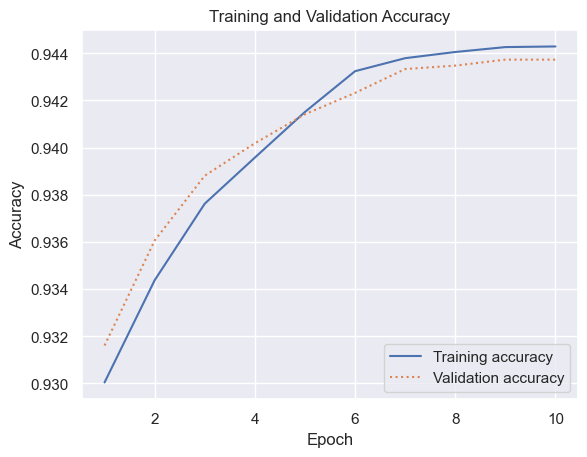

In [18]:
# CODE PROVIDED
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

acc = hist.history['accuracy']
val = hist.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, '-', label='Training accuracy')
plt.plot(epochs, val, ':', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.plot()

864/864 [==============================] - 1s 1ms/step
Accuracy: 0.9437
Recall: 0.2941
F1 Score: 0.4456
Precision: 0.9191


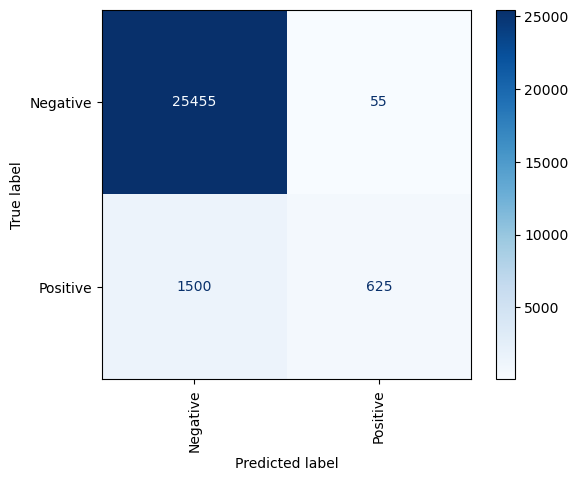

In [19]:
# CODE PROVIDED
from sklearn.metrics import ConfusionMatrixDisplay as cmd
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, ConfusionMatrixDisplay


sns.reset_orig()
y_predicted = model.predict(x_test) > 0.5

accuracy = accuracy_score(y_test, y_predicted)
recall = recall_score(y_test, y_predicted)
f1 = f1_score(y_test, y_predicted)
precision = precision_score(y_test, y_predicted)

print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")


labels = ['Negative', 'Positive']
cmd.from_predictions(y_test, y_predicted, display_labels=labels, cmap='Blues', xticks_rotation='vertical')

This confusion matrix makes it clear that we have more false negative diagnoses than false positive diagnoses. That's not what we want. Let's try take a closer look at our data.

### Dealing with Dataset Imbalance

Take a look at the `value_counts` for the `Corona` column in the original `covid` dataset.

In [22]:
print(covid['Corona'].value_counts())

Corona
0.0    127546
1.0     10626
Name: count, dtype: int64


We can see there is an imbalance in our data. Let's retrain our neural network for binary classification, and this time use the `class_weights` paramater of the `.fit()` method to try and handle the imbalanced nature of our data. We will be using the following formula to compute the `class_weights`: `[n_samples / (n_classes * freq)]`

Compute the class weight for each of the classes and store them in a dictionary called `class_weights` where the key is the binary value representing the class and the value is that class' weight. Then, retrain the neural network with the `class_weight` parameter set to the `class_weights` dictionary. Plot the training and validation accuracy, along with the confusion matrix.

In [24]:
# Count number of samples in training set
total_samples = len(y_train)

# Count of each class in training data
count_negative = sum(y_train == 0)
count_positive = sum(y_train == 1)

# Number of classes
n_classes = 2

# Compute class weights using the formula: n_samples / (n_classes * freq)
class_weights = {
    0: total_samples / (n_classes * count_negative),
    1: total_samples / (n_classes * count_positive)
}

# Preview the result
print("Class weights:", class_weights)


Class weights: {0: 0.5416568662040848, 1: 6.501411598635455}


In [25]:
from tensorflow import keras
from tensorflow.keras import layers

# Define the model with expected layer names
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(8,), name='dense'),
    layers.Dense(1, activation='sigmoid', name='dense_1')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
hist = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=100,
    validation_data=(x_test, y_test),
    class_weight=class_weights
)

# Print model summary to verify layer names and parameter counts
model.summary()


Epoch 1/10
1106/1106 [==============================] - 3s 2ms/step - loss: 0.4099 - accuracy: 0.8187 - val_loss: 0.4028 - val_accuracy: 0.8280
Epoch 2/10
1106/1106 [==============================] - 2s 2ms/step - loss: 0.3761 - accuracy: 0.8328 - val_loss: 0.3228 - val_accuracy: 0.8450
Epoch 3/10
1106/1106 [==============================] - 2s 2ms/step - loss: 0.3754 - accuracy: 0.8317 - val_loss: 0.3420 - val_accuracy: 0.8313
Epoch 4/10
1106/1106 [==============================] - 2s 2ms/step - loss: 0.3750 - accuracy: 0.8312 - val_loss: 0.3576 - val_accuracy: 0.8313
Epoch 5/10
1106/1106 [==============================] - 2s 2ms/step - loss: 0.3749 - accuracy: 0.8309 - val_loss: 0.3370 - val_accuracy: 0.8313
Epoch 6/10
1106/1106 [==============================] - 2s 2ms/step - loss: 0.3750 - accuracy: 0.8311 - val_loss: 0.3769 - val_accuracy: 0.8313
Epoch 7/10
1106/1106 [==============================] - 3s 2ms/step - loss: 0.3745 - accuracy: 0.8305 - val_loss: 0.3621 - val_accuracy:

[]

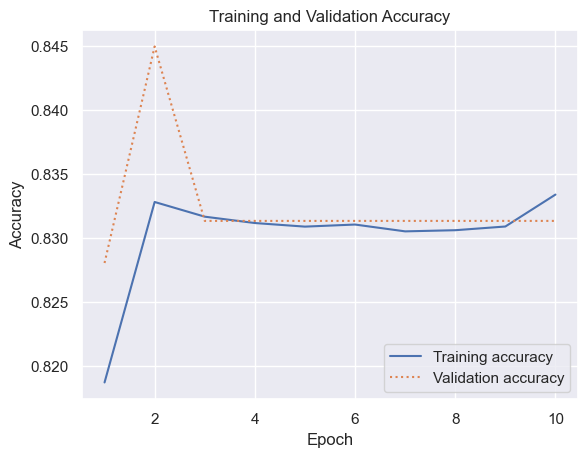

In [26]:
# CODE PROVIDED
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

acc = hist.history['accuracy']
val = hist.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, '-', label='Training accuracy')
plt.plot(epochs, val, ':', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.plot()

864/864 [==============================] - 1s 2ms/step
Accuracy: 0.8313
Recall: 0.8546
F1 Score: 0.4380
Precision: 0.2944


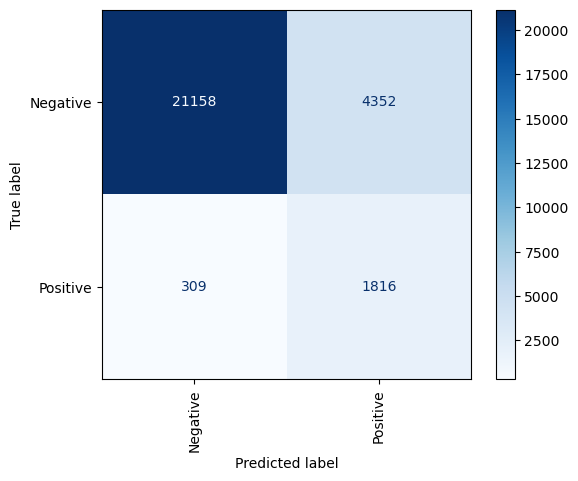

In [27]:
# CODE PROVIDED
from sklearn.metrics import ConfusionMatrixDisplay as cmd
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, ConfusionMatrixDisplay

sns.reset_orig()
y_predicted = model.predict(x_test) > 0.5

accuracy = accuracy_score(y_test, y_predicted)
recall = recall_score(y_test, y_predicted)
f1 = f1_score(y_test, y_predicted)
precision = precision_score(y_test, y_predicted)

print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")

labels = ['Negative', 'Positive']
cmd.from_predictions(y_test, y_predicted, display_labels=labels, cmap='Blues', xticks_rotation='vertical')

Our retrained model should perform much better: the number false negatives should be less than the number of false positives.

### Export datasets for codegrade evaluation
Using the "pickle" library:

Export the symptoms and diagnosis datasets

In [30]:
# CODE PROVIDED
import pickle

#Save dataset to file
with open('symptoms.pkl', 'wb') as file:
    pickle.dump(symptoms , file)   ## --> MAKE SURE TO EXPORT THE RIGHT DATASET

with open('diagnosis.pkl', 'wb') as file:
    pickle.dump(diagnosis , file)   ## --> MAKE SURE TO EXPORT THE RIGHT DATASET



### Export Models for codegrade evaluation
Using the "dill" library:

Export the trained model

In [32]:
# CODE PROVIDED
model.save('NN_BinayClass.h5')